In [11]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

#Load the dataset
df = pd.read_csv('players_data_with_all_info.csv')

print("Number of rows and columns:", df.shape)
print("\nFirst 5 rows:")
df.head()

Number of rows and columns: (17385, 16)

First 5 rows:


,id,firstname,lastname,fullname,image_path,dateofbirth,gender,battingstyle,bowlingstyle,position,updated_at,continent_id,continent_name,country_id,country_name,country_image_path
0,2,Ahmed,Shehzad,Ahmed Shehzad,https://cdn.sportmonks.com/images/cricket/play...,23-11-1991,m,right-hand-bat,legbreak,Batsman,2020-03-31T05:00:31.000000Z,2,Asia,52126,Pakistan,https://cdn.sportmonks.com/images/countries/pn...
1,3,Anwar,Ali,Anwar Ali,https://cdn.sportmonks.com/images/cricket/play...,25-11-1987,m,right-hand-bat,right-arm-fast-medium,Bowler,2020-12-14T18:58:56.000000Z,2,Asia,52126,Pakistan,https://cdn.sportmonks.com/images/countries/pn...
2,4,Sarfraz,Ahmed,Sarfraz Ahmed,https://cdn.sportmonks.com/images/cricket/play...,22-05-1987,m,right-hand-bat,right-arm-offbreak,Wicketkeeper,2020-04-07T08:51:02.000000Z,2,Asia,52126,Pakistan,https://cdn.sportmonks.com/images/countries/pn...
3,5,Azhar,Ali,Azhar Ali,https://cdn.sportmonks.com/images/cricket/play...,19-02-1985,m,right-hand-bat,legbreak,Batsman,2020-04-01T02:28:23.000000Z,2,Asia,52126,Pakistan,https://cdn.sportmonks.com/images/countries/pn...
4,6,Fakhar,Zaman,Fakhar Zaman,https://cdn.sportmonks.com/images/cricket/play...,10-04-1990,m,left-hand-bat,slow-left-arm-orthodox,Batsman,2020-04-02T02:22:22.000000Z,2,Asia,52126,Pakistan,https://cdn.sportmonks.com/images/countries/pn...


In [12]:
#Data Cleaning, Preprocessing

df['dateofbirth'] = pd.to_datetime(df['dateofbirth'], dayfirst=True, errors='coerce')
df['Age'] = 2024 - df['dateofbirth'].dt.year


df['Age'] = df['Age'].fillna(df['Age'].median())

#Simplify
def get_role(pos):
    pos = str(pos).lower()

    if 'batter' in pos or 'batsman' in pos:
        return 'Batsman'
    elif 'bowler' in pos and 'allrounder' not in pos:
        return 'Bowler'
    elif 'allrounder' in pos:
        return 'Allrounder'
    elif 'wicketkeeper' in pos:
        return 'Wicketkeeper'
    else:
        return 'Other'

df['role'] = df['position'].apply(get_role)

df = df[df['role'] != 'Other']

print("Roles in the dataset:")
print(df['role'].value_counts())

Roles in the dataset:
role
Bowler          5711
Batsman         5018
Allrounder      4964
Wicketkeeper    1692
Name: count, dtype: int64


In [13]:
#Preparation Machine Learning


df['battingstyle'] = df['battingstyle'].fillna('Unknown')
df['bowlingstyle'] = df['bowlingstyle'].fillna('Unknown')

le = LabelEncoder()

X = df[['battingstyle', 'bowlingstyle', 'continent_name', 'Age']].copy()

for col in ['battingstyle', 'bowlingstyle', 'continent_name']:
    X[col] = le.fit_transform(X[col])


target_le = LabelEncoder()
y = target_le.fit_transform(df['role'])

print("Features (X) - first 5 rows:")
print(X.head())
print("\nTarget labels (y):", target_le.classes_)

Features (X) - first 5 rows:
   battingstyle  bowlingstyle  continent_name   Age
0             2             4               1  33.0
1             2             7               1  37.0
2             2             8               1  37.0
3             2             4               1  39.0
4             1             9               1  34.0

Target labels (y): ['Allrounder' 'Batsman' 'Bowler' 'Wicketkeeper']


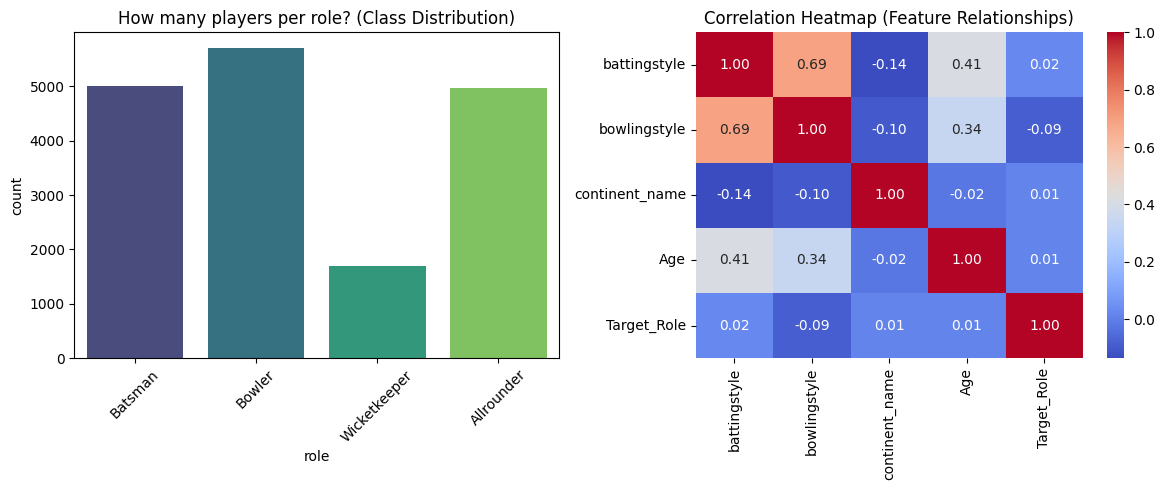

In [15]:
#EDA

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(x=df['role'], hue=df['role'], palette='viridis', legend=False)
plt.title("How many players per role? (Class Distribution)")
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
corr_df = X.copy()
corr_df['Target_Role'] = y
sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap (Feature Relationships)")

plt.tight_layout()
plt.show()

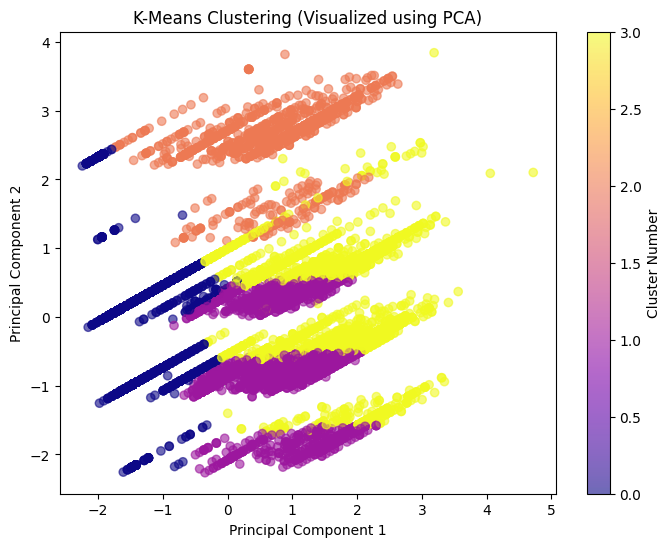

Clustering done! Each color represents a different cluster/group.


In [16]:
#Unsupervised Learning-K-Mean Clustering


from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

#PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='plasma', alpha=0.6)
plt.title("K-Means Clustering (Visualized using PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(scatter, label="Cluster Number")
plt.show()

print("Clustering done! Each color represents a different cluster/group.")

Training samples: 13908, Testing samples: 3477
Decision Tree Accuracy: 37.56%
Random Forest Accuracy: 36.84%
Neural Network Accuracy: 36.96%


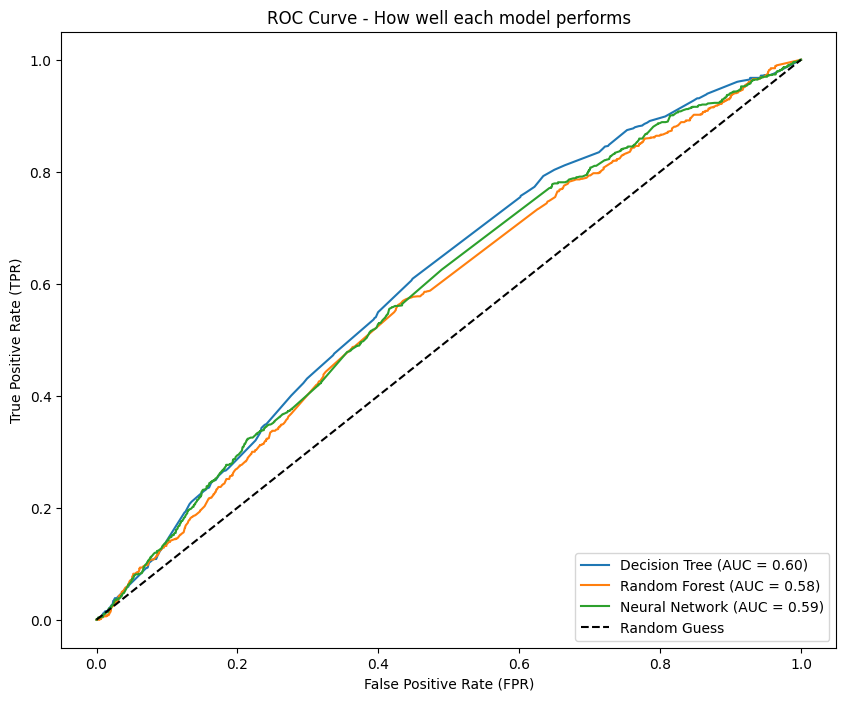

In [17]:
#Supervised Learning-Training 3 Different Models


from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, roc_curve, auc
from sklearn.preprocessing import label_binarize


X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print(f"Training samples: {len(X_train)}, Testing samples: {len(X_test)}")


models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=10, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(50, 50), max_iter=500, random_state=42)
}

accuracies = {}
plt.figure(figsize=(10, 8))

y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])

for name, model in models.items():

    model.fit(X_train, y_train)


    y_pred = model.predict(X_test)


    accuracies[name] = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {accuracies[name]:.2%}")

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)
        fpr, tpr, _ = roc_curve(y_test_bin[:, 1], y_prob[:, 1])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

#ROC
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.title("ROC Curve - How well each model performs")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.legend(loc="lower right")
plt.show()

/tmp/ipykernel_2390/946241774.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(accuracies.keys()), y=list(accuracies.values()), palette='mako')


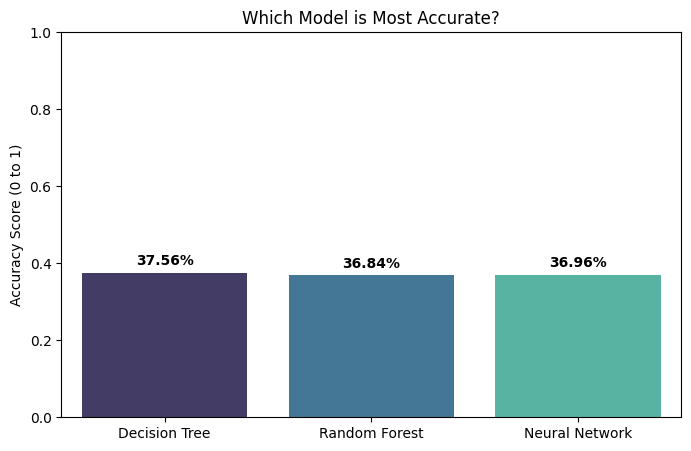


=== SUMMARY ===
Decision Tree: 37.56%
Random Forest: 36.84%
Neural Network: 36.96%

Best model: Decision Tree


In [18]:
#Accuracy Comparison Bar Chart
plt.figure(figsize=(8, 5))
sns.barplot(x=list(accuracies.keys()), y=list(accuracies.values()), palette='mako')
plt.title("Which Model is Most Accurate?")
plt.ylabel("Accuracy Score (0 to 1)")
plt.ylim(0, 1)


for i, v in enumerate(accuracies.values()):
    plt.text(i, v + 0.02, f"{v:.2%}", ha='center', fontweight='bold')

plt.show()

print("\n=== SUMMARY ===")
for name, acc in accuracies.items():
    print(f"{name}: {acc:.2%}")
print("\nBest model:", max(accuracies, key=accuracies.get))

In [19]:
#Predicted Roles vs Actual Roles

y_pred_best = models["Random Forest"].predict(X_test)

predicted_labels = target_le.inverse_transform(y_pred_best)
actual_labels = target_le.inverse_transform(y_test)

#first 15 results
results_df = pd.DataFrame({
    'Actual Role': actual_labels[:15],
    'Predicted Role': predicted_labels[:15],
    'Correct?': ['✓' if a == p else '✗' for a, p in zip(actual_labels[:15], predicted_labels[:15])]
})

print(results_df.to_string(index=False))

 Actual Role Predicted Role Correct?
     Batsman        Batsman        ✓
      Bowler         Bowler        ✓
     Batsman     Allrounder        ✗
      Bowler         Bowler        ✓
Wicketkeeper        Batsman        ✗
  Allrounder     Allrounder        ✓
      Bowler         Bowler        ✓
Wicketkeeper     Allrounder        ✗
  Allrounder         Bowler        ✗
Wicketkeeper         Bowler        ✗
      Bowler         Bowler        ✓
Wicketkeeper        Batsman        ✗
      Bowler        Batsman        ✗
     Batsman         Bowler        ✗
      Bowler         Bowler        ✓
